<center><p style = "background-color : lightblue; border-radius: 10px 10px; padding : 10px; font-size: 50px;"><strong>
<span style="color:#000">Нейросеть для классификации таблеток</span>
</strong></p></center>

<div class='alert alert-info'>

##### Актуальность задачи

На небольших фармацевтических предприятиях процесс фасовки часто включает ручной труд: специалист должен перепроверять каждую упаковку. Это не только трудоёмко и затратно по времени, но и чревато ошибками. Попадание в партию не той таблетки может привести к серьёзным последствиям для здоровья пациента — вплоть до угрозы жизни.

Частичная автоматизация (механическая расфасовка таблеток из большой ёмкости по маленьким упаковкам) не решает проблему полностью: финальный контроль всё ещё выполняется человеком. Возникает потребность в надёжном и быстром способе автоматической проверки содержимого упаковок.

#### Цель проекта

Разработать прототип алгоритма распознавания таблеток по фотографиям с помощью методов компьютерного зрения и свёрточных нейронных сетей (CNN). 

Решение должно:

* автоматически определять тип таблетки по изображению;
* интегрироваться в линию фасовки для мгновенной проверки каждой упаковки;
* достигать точности распознавания не менее 75 %.

#### Бизнес‑выгоды от внедрения

Внедрение такого классификатора принесёт предприятию ряд преимуществ:

* **Снижение риска ошибок.** Автоматизированный контроль минимизирует вероятность попадания в упаковку не тех таблеток.
* **Экономия времени и ресурсов.** Сокращение ручного труда освободит специалистов для более сложных задач.
* **Повышение доверия к продукции.** Гарантированная точность фасовки укрепит репутацию производителя и снизит юридические риски.
* **Масштабируемость.** Прототип можно доработать для работы с новыми типами таблеток и интегрировать в другие производственные процессы.

#### Техническая постановка задачи

Необходимо решить задачу **многоклассовой классификации изображений**:

* **Вход:** фотография таблетки на однотонном фоне (разное освещение, ракурсы).
* **Выход:** название таблетки (из заранее заданного списка классов).
* **Модель:** свёрточная нейронная сеть (CNN), обученная на [датасете](https://disk.yandex.ru/d/o4oQ4Yk7SpH1dw) венгерского Национального института фармации и питания (OGYEI).

#### Основные этапы проекта

1. Загрузка и предобработка данных.
2. Объявление и настройка модели.
3. Обучение или дообучение классификатора.
4. Оценка качества: расчёт метрик (Precision, Recall, F1, accuracy) и анализ ошибок.


<center><p style = "background-color : lightblue; border-radius: 10px 10px; padding : 10px; font-size: 30px;"><strong>
<span style="color:#000">Импорт используемых библиотек</span>
</strong></p></center>

In [1]:
import os
import time


import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns


import torch.nn as nn
import torchvision.models as models
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from torchvision.transforms import (
    ColorJitter,
    Compose,
    Normalize,
    RandomHorizontalFlip,
    RandomRotation,
    RandomVerticalFlip,
    Resize,
    ToTensor,
)

from PIL import Image
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

<div class='alert alert-info'>
С целью оптимизации производительности, ускорения обучения нейронных сетей на GPU, и предотвращения ошибок по нехватки памяти выполним небольшую настройку и выведем основные характеристики устройства.
<div>

In [2]:
# Очистка памяти перед началом работы
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

# Оптимизация управления памятью CUDA
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

# Оптимизации CUDA
torch.backends.cudnn.benchmark = True
torch.backends.cudnn.deterministic = False
if torch.cuda.is_available():
    torch.set_float32_matmul_precision('high')
    
    
# Настройки устройства
device = torch.device("cuda")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


Using device: cuda
GPU: NVIDIA GeForce RTX 4070
VRAM: 12.9 GB


<div class='alert alert-info'>
Добавим небольшой пульт управления 
<div>

In [3]:
# Путь к корневой папке с данными
DATA_DIR = r"D:\code\ya_neiro\PROJECT_NLP_CV_LLM\Нейросеть для классификации таблеток\data\ogyeiv2"

# Гипперпараметры обучения  
BATCH_SIZE = 64    # Размер батча
NUM_WORKERS = 8    # Количество потоков для загрузки данных
EPOCHS = 10        # Количество эпох обучения

<center><p style = "background-color : lightblue; border-radius: 10px 10px; padding : 10px; font-size: 30px;"><strong>
<span style="color:#000">Загрузка и предобработка данных</span>
</strong></p></center>

In [4]:
train_path = os.path.join(DATA_DIR, "train")
test_path = os.path.join(DATA_DIR, "test")

<div class='alert alert-info'>
Для загрузки и подготовки данных перед обучением соберем Compose пайплайн трансформации изображения для нейросетей.
<br>
<br>
В данной работе пайплай состоит из следующих трансформаций:

**Для обучающего датасета**

| Трансформация | Что делает | Зачем |
|--------------|------------|-------|
| **RandomHorizontalFlip(p=0.3)** | Отражает изображение по горизонтали с вероятностью 30% | Увеличивает разнообразие данных, модель учится инвариантности к отражениям |
| **RandomVerticalFlip(p=0.3)** | Отражает изображение по вертикали с вероятностью 30% | Учит модель распознавать объекты в перевёрнутом виде |
| **ColorJitter(brightness=0.1, contrast=0.1)** | Случайно меняет яркость и контрастность | Модель становится устойчива к разным условиям освещения |
| **Resize((224, 224))** | Изменяет размер всех изображений до 224×224 пикселей | Стандартный входной размер для предобученных моделей |
| **RandomRotation([-5, 5], fill=255)** | Поворачивает изображение на угол от -5 до +5, пустые области заполняет белым (255)| Учит модель распознавать объекты под небольшим наклоном |
| **ToTensor()** | Преобразует PIL Image или numpy array в тензор PyTorch и меняет размерность с (H,W,C) на (C,H,W) | PyTorch работает только с тензорами |
| **Normalize(mean=[...], std=[...])** | Нормализует пиксели: **(x - mean) / std** | Приводит данные к распределению, на котором обучена предобученная модель (ImageNet) |

**Для тестового датасета**

| Трансформация | Что делает | Зачем |
|--------------|------------|-------|
| **Resize((224, 224))** | Изменяет размер | Должен совпадать с размером обучающих данных |
| **ToTensor()** | Преобразует в тензор | Аналогично обучению |
| **Normalize(mean=[...], std=[...])** | Нормализует | Аналогично обучению, чтобы данные были в одном формате |

<div>

<div class='alert alert-warning'>

**Это не единственые возможные трансформации, и вданном проекте было проведено множество подходов подборов параметров трансформации, спустя определенный период проб и ошибок принято решение оставить их в следующием виде:** 

In [5]:
# Трансформации для обучающего датасета
train_tf = Compose([
    RandomHorizontalFlip(p=0.3),
    RandomVerticalFlip(p=0.3),
    ColorJitter(brightness=0.1, contrast=0.1),
    Resize((224, 224)),
    RandomRotation([-5, 5], fill=255),
    ToTensor(),
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


# Трансформации для валидационного датасета 
val_tf = Compose([
    Resize((224, 224)),
    ToTensor(),
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Загружаем датасеты напрямую с трансформациями
train_dataset = ImageFolder(train_path, transform=train_tf)
val_dataset = ImageFolder(test_path, transform=val_tf)

# Выводим информацию
num_classes = len(train_dataset.classes)
print(f"Количество классов: {num_classes}")
print(f"Классы: {train_dataset.classes}")
print(f"Обучающий датасет: {len(train_dataset)}")
print(f"Валидационный датасет: {len(val_dataset)}")

Количество классов: 84
Классы: ['acc_long_600_mg', 'advil_ultra_forte', 'akineton_2_mg', 'algoflex_forte_dolo_400_mg', 'algoflex_rapid_400_mg', 'algopyrin_500_mg', 'ambroxol_egis_30_mg', 'apranax_550_mg', 'aspirin_ultra_500_mg', 'atoris_20_mg', 'atorvastatin_teva_20_mg', 'betaloc_50_mg', 'bila_git', 'c_vitamin_teva_500_mg', 'calci_kid', 'cataflam_50_mg', 'cataflam_dolo_25_mg', 'cetirizin_10_mg', 'cold_fx', 'coldrex', 'concor_10_mg', 'concor_5_mg', 'condrosulf_800_mg', 'controloc_20_mg', 'covercard_plus_10_mg_2_5_mg_5_mg', 'coverex_4_mg', 'diclopram_75-mg_20-mg', 'dorithricin_mentol', 'dulsevia_60_mg', 'enterol_250_mg', 'favipiravir_meditop_200_mg', 'ibumax_400_mg', 'jutavit_c_vitamin', 'jutavit_cink', 'kalcium_magnezium_cink', 'kalium_r', 'koleszterin_kontroll', 'lactamed', 'lactiv_plus', 'laresin_10_mg', 'letrox_50_mikrogramm', 'lordestin_5_mg', 'merckformin_xr_1000_mg', 'meridian', 'metothyrin_10_mg', 'mezym_forte_10_000_egyseg', 'milgamma', 'milurit_300_mg', 'naprosyn_250_mg', 'narv

<div class='alert alert-info'>

**Теперь непосредственно перейдем к Dataloader**
<br>
<br>

***Это является основной болью для меня в проекте, потому что GPU ни в какую не хотела работать при установлении паралельной загрузки процессов для загрузки и модель просто зависала и могла крутиться часами.Удалось настроить при помощи оптимизации cuda, хотя не уверен, что в этом дело. Пусть это будет магией***


## Параметры train_loader

| Параметр  | Что делает | Зачем |
|----------|------------|-------|
| **train_dataset**  | Источник данных | Откуда брать изображения и метки |
| **batch_size** | Сколько изображений за одну итерацию | Баланс между скоростью и памятью GPU |
| **shuffle=True**  | Перемешивает данные перед каждой эпохой | Чтобы модель не запоминала порядок, уменьшает переобучение |
| **pin_memory=True** | Блокирует память CPU (не позволяет перемещать в swap) | Ускоряет передачу данных на GPU в 2-3 раза |
| **num_workers** | Количество подпроцессов для загрузки | Параллельная загрузка |
| **persistent_workers=True**  | Не убивает процессы после каждой эпохи | Ускоряет начало каждой эпохи (процессы живут всё обучение) |
| **prefetch_factor**  | Загружает вперёд батчи | Пока GPU считает, CPU готовит следующие батчи — нет простоев |

## Параметры val_loader

| Параметр | Что делает | Зачем |
|----------|------------|-------|
| **val_dataset**  | Источник данных | Откуда брать изображения для проверки |
| **batch_size**  | Сколько изображений за раз | Та же пачка, что и в обучении |
| **shuffle=False** | Не перемешивает | Для валидации порядок не важен, важна стабильность |
| **pin_memory=True**  | Блокирует память CPU | Ускоряет передачу на GPU |
| **num_workers=NUM_WORKERS // 2**  | Меньше процессов | Для валидации не нужна максимальная скорость |
| **persistent_workers=True** | Процессы не перезапускаются | Ускоряет валидацию между эпохами |

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True,
    num_workers=NUM_WORKERS,
    persistent_workers=True, 
    prefetch_factor=4        
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE, 
    shuffle=False,
    pin_memory=True,
    num_workers=NUM_WORKERS // 2,
    persistent_workers=True,
)


<center><p style = "background-color : lightblue; border-radius: 10px 10px; padding : 10px; font-size: 30px;"><strong>
<span style="color:#000">Объявление модели</span>
</strong></p></center>

<div class='alert alert-info'>
 
#### **Сразу введу в курс дела, в работе проводились эксперементы со следующими моделями:**
- **ResNet18**
- **ResNet50**
- **MobileNetV3-Small**
- **EfficientNet-B0**
- **EfficientNet-B3**
- **EfficientNet-B4**


**Небольшая инфа по моделькам:**
| Модель | Архитектура | Плюсы | Минусы |
|--------|------------|-------|--------|
| **ResNet18** | 18 слоев (17 conv + 1 fc), residual blocks с skip connections, выход 512 каналов | Легкая и быстрая (11.7M параметров). Меньше склонна к переобучению. Лучший баланс скорость/точность Стабильная сходимость | Меньше capacity для сложных паттернов |
| **ResNet50** | 50 слоев (48 conv + 2 fc), bottleneck blocks (1x1→3x3→1x1 conv), выход 2048 каналов | Мощная архитектура. Лучше извлекает сложные признаки. Отлично работает на ImageNet | Тяжелая (25.6M параметров). Медленнее обучение. Сильно склонна к переобучению |
| **MobileNetV3-Small** | MBConv (mobile inverted bottleneck), squeeze-excitation blocks, h-swish активации | Экстремально легкая (2.5M параметров). Самый быстрый инференс. Оптимизирована для мобильных устройств | Низкая capacity. Плохо справляется со сложными данными. Низкая точность на малых объектах |
| **EfficientNet-B0** | Compound scaling (width×depth×resolution), MBConv blocks, squeeze-excitation | Оптимальный баланс параметров (5.3M). Хорошее соотношение точность/параметры Современная архитектура | Медленнее ResNet18 на инференсе. Сложнее в настройке |
| **EfficientNet-B3** | Увеличенная версия B0, больше каналов, глубже, вход 300×300 | Лучшая точность среди EfficientNet. Хороша для сложных датасетов. Эффективное использование параметров (12.2M) | Тяжелее и медленнее. Выше риск переобучения |
| **EfficientNet-B4** | Максимальная версия в линейке B, вход 380×380, максимальная глубина | Максимальная точность. Лучшая для ImageNet. Извлекает самые сложные признаки | Самая тяжелая (19.3M параметров). Самый медленный инференс. Требует много VRAM (>8GB). Сильно переобучается на малых данных |

**В нашем случае вышло ровно так как изложено в основных плюсах и минусах по моделям, в основном ResNet50 и EfficientNet - переобучались на наших данных, MobileNetV3-Small - слабо обучался, и давал худшие результаты точности, самым оптимальным я выбрал ResNet18, почему? Потому что:**

- **Устойчивость к переобучению** — самое важное было для меня;
- **Скорость обучения** — ~60 сек/эпоха позволяля быстро экспериментировать;
- **Стабильность** — меньше проблем с градиентами и сходимостью.

**Безусловно можно настроить и другие приведенные модели вопрос в заморозке и настройки слоев...**

**кароче говоря ближе к делу:**

In [7]:
# Загрузка предобученной модели ResNet18
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Взгялянем на архитектуру модели
display(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

<div class='alert alert-info'>

**Структуру нового классификатора зададим в таком виде:**

```html
Вход (признаки от backbone) → 512 признаков
         ↓
    Dropout(0.5)      # Отключаем 50% нейронов
         ↓
    Linear(512, 512)  # Полносвязный слой (сохраняем размерность)
         ↓
        ReLU()        # Нелинейность
         ↓
    Dropout(0.5)      # Снова отключаем 50% нейронов
         ↓
    Linear(512, num_classes)  # Выход на N классов
         ↓
    Выход (логиты)
```

In [8]:
# Размораживаем все слои для дообучения
for param in model.parameters():
    param.requires_grad = True

# Зададим количество входных признаков для финального слоя
num_features = model.fc.in_features


# Заменяем классификатор на новый
model.fc = nn.Sequential(
    nn.Dropout(0.5),  # Регуляризация
    nn.Linear(num_features, 512), # преобащение признаков
    nn.ReLU(), # Активация ReLU для нелинейности
    nn.Dropout(0.5),  # дополнительный слой Dropout
    nn.Linear(512, num_classes) # Выход на количество классов
)


# Переносим модель на GPU
model = model.to(device)

# Выводим количество обучаемых параметров для контроля
print(f"Количество обучаемых параметров: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


Количество обучаемых параметров: 11,482,260


In [9]:
# Проверочка
display(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

<div class='alert alert-info'>
Готово, можно переходить уже к следующему этапу
</div>

<center><p style = "background-color : lightblue; border-radius: 10px 10px; padding : 10px; font-size: 30px;"><strong>
<span style="color:#000">Обучение нашей модельки</span>
</strong></p></center>

<div class='alert alert-info'>

Для начала:
- Зададим функцию потерь для классификации
- Вызовим оптимизатор для обновления веса модели на основе градиентов
- Вызовим планировщик скорости обучения

А также напишем вызовим инструмент для автоматического смешанного обучения с целью ускорения на GPU **GradScaler**

Что там происходит? А вот что - обычно модель обучается в float32 (32-битная точность). А смешанное обучение использует float16 (16-битная точность) для большинства операций и float32 только где нужно.

Не обязательная вещь, но мне помогло ускорить, я его решил оставить.

In [10]:
# Функция потерь
criterion = nn.CrossEntropyLoss()

# Оптимизатор
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-3)


# Планировщик
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3, verbose=True
)

# Смеситель наш
from torch.amp import autocast, GradScaler
scaler = GradScaler('cuda')

C:\Users\xndrf\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


<div class='alert alert-info'>
Создадим пайплайн обучения с оптимизацией производительности и полным контролем метрик, кароче говоря делаем функции train_epoch и eval_epoch

In [11]:
def train_epoch(model, loader, criterion, optimizer, scaler, device):
    """Функция обучения на одну эпоху

    Args:
        model (_type_): модель для обучения
        loader (_type_): даталоадер для обучения
        criterion (_type_): функция потерь
        optimizer (_type_): оптимизатор для обновления весов
        scaler (_type_):  Скейлер для автоматической смешанной точности
        device (_type_): устройство для обучения GPU в нашем случае
        
    """ 
    
    # Переводим модель в режим обучения и инициализируем счетчики   
    model.train()
    running_loss = 0
    correct = 0
    total = 0
    
    # Идем по батчам из даталоадера
    for i, (imgs, labels) in enumerate(loader):
        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        
        # Оптимизируем память, обнуляя градиенты
        optimizer.zero_grad(set_to_none=True)
        
        with autocast('cuda', dtype=torch.float16):
            outputs = model(imgs)
            loss = criterion(outputs, labels)
        
        # Обратный проход с масштабированием
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        # Подсчет метрик
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    # Вычисляем средние значение и точность
    avg_loss = running_loss / len(loader)
    accuracy = 100. * correct / total
    

    return avg_loss, accuracy

def eval_epoch(model, loader, criterion, device):
    """Функция валидации на одну эпоху

    Args:
        model (_type_): модель для валидации
        loader (_type_): даталоадер для валидации
        criterion (_type_): функция потерь
        device (_type_): устройство для валидации
    """    
    
    model.eval()
    running_loss = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            
            # НОВЫЙ СИНТАКСИС
            with autocast('cuda', dtype=torch.float16):
                outputs = model(imgs)
                loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            
            # Сохраняем предсказания
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    avg_loss = running_loss / len(loader)
    accuracy = accuracy_score(all_labels, all_preds)
    
    return avg_loss, accuracy, all_preds, all_labels

<div class='alert alert-info'>

А далее реализуем наш полный цикл обучения модели с мониторингом, сохранением лучшей версии и логированием.
А также выводом номеров эпох, времени, метрик обучения и валидации. Ну и с сохранением / пересохранением лучшей модельки

In [ ]:
# Точность наша
best_val_acc = 0
# Сделаем дневничек обучения
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}


# Прогрев GPU
print("Прогрев GPU...")
warmup_imgs, warmup_labels = next(iter(train_loader))
warmup_imgs = warmup_imgs.to(device, non_blocking=True)
with autocast('cuda', dtype=torch.float16):
    _ = model(warmup_imgs)
torch.cuda.synchronize()
print("Готово, можно жать газ на обучение!\n")

for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()
    
    # Обучение
    train_loss, train_acc = train_epoch(
        model, train_loader, criterion, optimizer, scaler, device
    )
    
    # Валидация
    val_loss, val_acc, val_preds, val_labels = eval_epoch(
        model, val_loader, criterion, device
    )
    
    # Обновляем learning rate
    scheduler.step(val_loss)
    
    # Сохраняем историю
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    epoch_time = time.time() - epoch_start
    
    # Сохраняем лучшую модель
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), '/model/meds_classifier.pth')
        print(f"Модель сохранена (acc: {val_acc:.4f})")
    
    # Вывод
    print(f"\nEpoch {epoch}/{EPOCHS} [{epoch_time:.1f}s]")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    print("-"*60)

Прогрев GPU...
Готово, можно жать газ на обучение!

Модель сохранена (acc: 0.0972)

Epoch 1/10 [118.0s]
  Train Loss: 4.4467 | Train Acc: 1.74%
  Val Loss:   4.2031 | Val Acc:   0.0972
------------------------------------------------------------
Модель сохранена (acc: 0.3175)

Epoch 2/10 [66.3s]
  Train Loss: 4.1358 | Train Acc: 8.16%
  Val Loss:   3.6696 | Val Acc:   0.3175
------------------------------------------------------------
Модель сохранена (acc: 0.4901)

Epoch 3/10 [67.0s]
  Train Loss: 3.6675 | Train Acc: 18.92%
  Val Loss:   2.9807 | Val Acc:   0.4901
------------------------------------------------------------
Модель сохранена (acc: 0.5536)

Epoch 4/10 [67.4s]
  Train Loss: 3.1226 | Train Acc: 30.99%
  Val Loss:   2.3532 | Val Acc:   0.5536
------------------------------------------------------------
Модель сохранена (acc: 0.6329)

Epoch 5/10 [66.6s]
  Train Loss: 2.5625 | Train Acc: 43.20%
  Val Loss:   1.9761 | Val Acc:   0.6329
----------------------------------------

<div class='alert alert-info'>

**Коротко по результатам:**

- Модель обучается корректно, и вроде никаких признаков застревания или взрыва градиентов не обнаружил.
- $Val Acc > Train Acc$ на первых эпохах.. Может быть это из-за регуляризации..
- На последних эпохах: $Train Acc < 80%$, $Val Acc > 93%$, может казаться, что присутствует лёгкое переобучение на мелких классах, но я посчитал что необходимо стремиться ближе к 90-95% на обучение, потому что модель относится к медицинской сфере и тут важна высокая точность. Кароче говоря оставим как есть
- касаьтельно скорости обучения, не обращая внимания на прогрев и первую эпоху то скорость обучения: ~60–70 сек/эпоха, что считаю нормальным при нашем BATCH_SIZE на GPU.

**В целом могу сказать, что модель хорошо подходит для классификации таблеток.**

In [13]:
# Сбор всех предсказаний
model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(dim=1)
        
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Используем классы из val_dataset или train_dataset
class_names = val_dataset.classes 

print("Вывод метрик для каждого класса (Precision, Recall, F1)\n")
print(classification_report(y_true, y_pred, target_names=class_names))

# Общая accuracy
accuracy = accuracy_score(y_true, y_pred)
print(f"\nИтоговая accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

Вывод метрик для каждого класса (Precision, Recall, F1)

                                  precision    recall  f1-score   support

                 acc_long_600_mg       1.00      1.00      1.00         6
               advil_ultra_forte       1.00      1.00      1.00         6
                   akineton_2_mg       1.00      1.00      1.00         6
      algoflex_forte_dolo_400_mg       1.00      1.00      1.00         6
           algoflex_rapid_400_mg       1.00      1.00      1.00         6
                algopyrin_500_mg       1.00      1.00      1.00         6
             ambroxol_egis_30_mg       1.00      1.00      1.00         6
                  apranax_550_mg       1.00      1.00      1.00         6
            aspirin_ultra_500_mg       0.60      1.00      0.75         6
                    atoris_20_mg       1.00      1.00      1.00         6
         atorvastatin_teva_20_mg       0.67      1.00      0.80         6
                   betaloc_50_mg       1.00      1.00 

<div class='alert alert-info'>

Добавим не много визуализации:

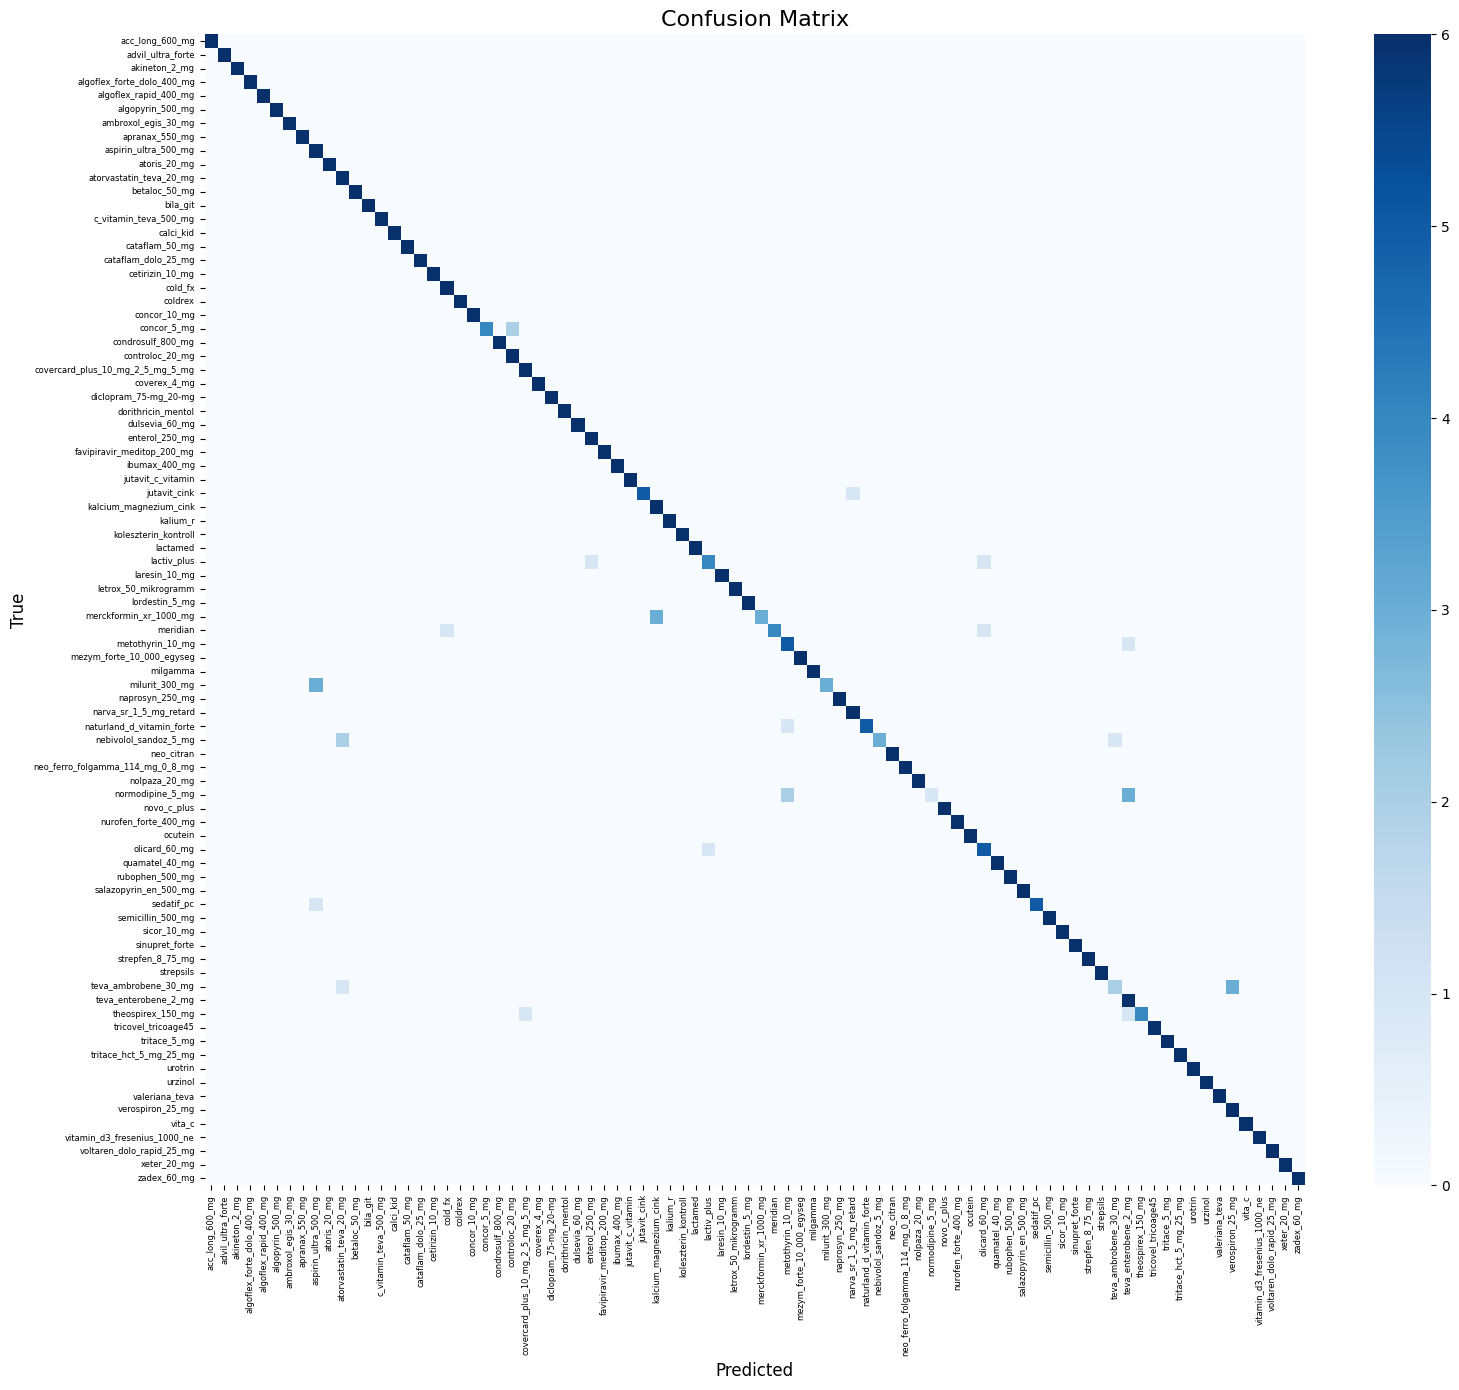

In [14]:
# Строим матрицу ошибок
plt.figure(figsize=(16, 14))
cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names)
plt.title('Confusion Matrix', fontsize=16)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.xticks(rotation=90, fontsize=6)
plt.yticks(rotation=0, fontsize=6)
plt.tight_layout()
plt.show()

<div class='alert alert-info'>

### Основные выводы:

**Топ-5 классов с наибольшим количеством ошибок**

Ошибки выявлены на основе метрики **recall**. Суть в чём - чем ниже recall, тем чаще модель пропускает этот класс :

| Класс | Recall | F1-score |
|-------|--------|----------|
| normodipine_5_mg | 0.17 | 0.29 |
| teva_ambrobene_30_mg | 0.33 | 0.44 |
| merckformin_xr_1000_mg | 0.50 | 0.67 |
| milurit_300_mg | 0.50 | 0.67 |
| nebivolol_sandoz_5_mg | 0.50 | 0.67 

**Вывод:** именно эти 5 классов модель распознаёт хуже всего. Остальные классы имеют recall в диапазоне 0.67–1.0.


**Возможные причины ошибок на проблемных классах**

1. Недостаток обучающих данных, в теории если на эти классы приходится мало изображений, модель не видит достаточного разнообразия вариаций (освещение, угол съёмки, фон). Необходимо либо доработать ручками эти классы, сделать дополнительные фотографии или улучшить их качество и пополнить датасет;
2. В теории может быть визуальная схожесть с другими классами, т.е. цвет, форма, размер таблетки, что приводит к путанице;
3. Аугментации **RandomRotation**, **ColorJitter** и другие трансформации могут искажать ключевые признаки, особенно для редких или мелких классов. В качестве рекомендаций можно поэскперементировать с признаками.
4. Возможно регуляризация - Dropout (0.5) улучшает обобщение, но может размывать специфические детали, важные для различения похожих классов.

**Что касается классов без ошибок (recall = 1.0), их достаточно много, перечислять все не вижу смысла, вот парочка которые модель распознает идеально:**
- acc_long_600_mg
- advil_ultra_forte
- akineton_2_mg
- algoflex_forte_dolo_400_mg
- algoflex_rapid_400_mg
- algopyrin_500_mg
- ambroxol_egis_30_mg
- и большинство остальных классов

**Почему эти классы распознаются безошибочно?**

- Модель видела много примеров и выучила вариации.
- Ярко выраженные форма, цвет, надписи.
- Минимальное визуальное пересечение с другими классами.
- А возможно мы и переобучили :D. Надо проводить дополнительные тесты.

**Что касается рекомендации по улучшению модели**

1. Во первых данные:
- Собрать больше данных для проблемных классов:
- Использовать балансировку классов:
  - WeightedRandomSampler
  - Oversampling редких классов

2. Попробовать более мощные архитектуры
- ResNet50
- EfficientNet-B3/B4
- ConvNeXt-Tiny

Но по мне так, для наших данных и объемах достаточно и ResNet18, с мощными моделями и обучение дольше, и вероятность переобучения выше, как говорил ранее при выборе модели. Но возможна и более тонкая настройка моделей и тогда будет успех.

3. Опять же вернуться к аугментации и внедрить адаптивные вещи, такие как:
- RandomAffine
- RandomPerspective
- CutMix / MixUp
- Уменьшить агрессивность аугментаций для редких классов


**Что касается дополнительных методов анализа ошибок, то можно предложить следующие:**

| Метод | Назначение |
|-------|------------|
| Confusion Matrix | Показывает, какие классы чаще всего путаются между собой |
| Grad-CAM / Attention Maps | Визуализация областей, на которые "смотрит" модель при принятии решения |
| Loss per class | Вычисление среднего loss для каждого класса — сразу видны "слабые" места |
| Визуальный просмотр ошибок | Анализ misclassified samples: ищем схожесть, плохое качество, артефакты |
| K-Fold Cross-Validation | Проверяет стабильность модели и исключает случайность разбиения данных |





### **Accuracy 93.85%**
